In [127]:
##Borrar datos del entorno
rm(list=ls())


#Se utiliza pacman para instalar y cargar paquetes
if(!require('pacman')) install.packages('pacman')
pacman::p_load(tidyverse,janitor,ARDL,gridExtra,showtext)
font_add_google("Poppins", "pop")
showtext_auto()

In [ ]:
##Leer datos
indices<-openxlsx::read.xlsx("indices_precios_base_2019.xlsx")
head(indices,5)

,fecha,inpc,alimentos_bebidas_tabaco,ropa_calzado_accesorios,vivienda,muebles_aparatos_domesticos,salud_cuidado_personal,transporte,educacion_esparcimiento,otros_servicios,inpp_sin_pet_con_serv,inpp_con_pet_con_serv,ferrocarril,autotransporte_carga
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,29587,0.06328191,0.05864788,0.1164437,0.08643196,0.1186103,0.05249415,0.03752696,0.04795345,0.03632621,NA,NA,0.03521193,0.09101092
2,29618,0.06483631,0.05965725,0.1192355,0.08872053,0.1219927,0.05485624,0.03963287,0.04862881,0.03723676,NA,NA,0.04332105,0.09101092
3,29646,0.06622322,0.06070432,0.1221916,0.09114541,0.1250916,0.05642632,0.04043428,0.04966391,0.03804787,NA,NA,0.04332105,0.09101092
4,29677,0.06771672,0.06188605,0.1256665,0.09296936,0.1279841,0.05744173,0.04114553,0.05077894,0.03947001,NA,NA,0.04332105,0.09101092
5,29707,0.06874099,0.06290511,0.1282300,0.09382373,0.1301111,0.05843429,0.04154735,0.05170240,0.04003192,NA,NA,0.04332105,0.09101092


In [ ]:
#Función para estimar el modelo

run_ardl_model <- function(
    data,
    date_var,
    dep_var,
    indep_vars,
    seleccion_modelo = NULL, # Puede ser "AIC", "BIC" o NULL
    max_order = 4,
    case = 3,
    plot_results = TRUE
) {
  
  # 1. Limpieza de datos
  df <- data %>%
    select(all_of(c(date_var, dep_var, indep_vars))) %>%
    na.omit() %>%
    mutate(!!date_var := as.Date(.data[[date_var]])) %>%
    arrange(.data[[date_var]])

  formula_ardl <- as.formula(paste(dep_var, "~", paste(indep_vars, collapse = " + ")))

  # 2. LÓGICA DE SELECCIÓN
  if (is.null(seleccion_modelo)) {
    cat("\n[INFO] Modo automático: Evaluando el modelo más preciso...\n")
    
    # Comparamos internamente
    mod_aic  <- auto_ardl(formula_ardl, data = df, max_order = max_order, selection = "AIC")
    mod_bic  <- auto_ardl(formula_ardl, data = df, max_order = max_order, selection = "BIC")
    
    # Extraemos el error estándar (Sigma) de cada uno
    sigmas <- c(AIC = summary(mod_aic$best_model)$sigma, 
                BIC = summary(mod_bic$best_model)$sigma)
    
    # Se selecciona el que tenga el error más bajo
    ganador <- names(which.min(sigmas))
    seleccion_usada <- paste(ganador, "(detectado como mejor ajuste)")
    
    # Asignamos el modelo ganador
    if(ganador == "AIC")  resultado_auto <- mod_aic
    if(ganador == "BIC")  resultado_auto <- mod_bic
    
  } else {
    # Si se especifica (AIC, BIC)
    seleccion_usada <- seleccion_modelo
    resultado_auto <- auto_ardl(
      formula = formula_ardl, 
      data = df, 
      max_order = max_order, 
      selection = seleccion_modelo
    )
  }

  modelo_final <- resultado_auto$best_model

  # 3. REPORTES
  cat("\n", rep("=", 60), "\n   REPORTE FINAL DE MODELO ARDL\n", rep("=", 60), "\n", sep="")
  cat("Criterio final aplicado:", seleccion_usada, "\n")
  cat("Orden (p, q1, q2...):", paste(modelo_final$order, collapse = ", "), "\n")
  
  # Check de Persistencia
  coefs_dep <- coef(modelo_final)[grep(paste0("^", dep_var, "\\.L"), names(coef(modelo_final)))]
  cat("Persistencia de la serie:", round(sum(coefs_dep), 4), "\n")

  print(summary(modelo_final))
  
  # Cointegración y Largo Plazo
  bt <- bounds_f_test(modelo_final, case = case)
  lr <- coint_eq(modelo_final, case = case)
  
  cat("\n--- BOUNDS TEST ---\n"); print(bt)
  cat("\n--- LARGO PLAZO ---\n"); print(lr)

  # 4. GRÁFICAS
  if (plot_results) {
    ajustados <- as.numeric(fitted(modelo_final))
    reales <- modelo_final$model[[1]]
    residuos <- residuals(modelo_final)
    fechas_sync <- tail(df[[date_var]], length(ajustados))
    
    df_plot <- data.frame(Fecha = fechas_sync, Real = reales, Ajustado = ajustados, Res = residuos)
    
    p1 <- ggplot(df_plot, aes(x = Fecha)) +
      geom_line(aes(y = Real, color = "Observado"), size = 1.5) +
      geom_line(aes(y = Ajustado, color = "Predicho"), linetype = "dashed", size = 1.5) +
      scale_color_manual("Series",values = c("Observado" = "black", "Predicho" = "firebrick")) +
      labs(title = "Ajuste ARDL", subtitle = paste("Criterio:", seleccion_usada), x = NULL,
      y="Índice"
      
      ) +
      theme_minimal()+      theme(
            plot.title = element_text(hjust = 0, size=30,face="bold"),
            plot.subtitle = element_text(hjust = 0, size=20, face="italic"),
            plot.caption = element_text(hjust = 0,size=15),
            axis.text.x = element_text(angle = 90, vjust = 0.5,size=15),
            text=element_text("pop",size=20))

    p2 <- ggplot(df_plot, aes(x = Fecha, y = Res)) +
      geom_hline(yintercept = 0, color = "blue", linetype = "dashed") +
      geom_line(color = "steelblue") +
      labs(title = "Residuos (Errores)", x = "Fecha") +
      theme_minimal()+
            theme(
            plot.title = element_text(hjust = 0, size=30,face="bold"),
            plot.subtitle = element_text(hjust = 0, size=20, face="italic"),
            plot.caption = element_text(hjust = 0,size=15),
            axis.text.x = element_text(angle = 90, vjust = 0.5,size=15),
            text=element_text("pop",size=20))

    grid.arrange(p1, p2, ncol = 1, heights = c(2, 1))
  }
  
  return(invisible(list(modelo = modelo_final, bounds = bt, largo_plazo = lr)))
}

[1] "Incidencia ferrocarril en alimentos"

[INFO] Modo automático: Evaluando el modelo más preciso...

   REPORTE FINAL DE MODELO ARDL
Criterio final aplicado: AIC (detectado como mejor ajuste) 
Orden (p, q1, q2...): 4, 4 
Persistencia de la serie: 0 

Time series regression with "ts" data:
Start = 5, End = 540

Call:
dynlm::dynlm(formula = full_formula, data = data, start = start, 
    end = end)

Residuals:
     Min       1Q   Median       3Q      Max 
-3.04347 -0.13380 -0.03911  0.16014  1.91549 

Coefficients:
                                Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     0.079284   0.030195   2.626 0.008899 ** 
L(alimentos_bebidas_tabaco, 1)  1.301664   0.043374  30.010  < 2e-16 ***
L(alimentos_bebidas_tabaco, 2) -0.462264   0.070983  -6.512 1.73e-10 ***
L(alimentos_bebidas_tabaco, 3)  0.239444   0.071287   3.359 0.000839 ***
L(alimentos_bebidas_tabaco, 4) -0.077874   0.044010  -1.769 0.077398 .  
ferrocarril                    -0.009979  

Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.
Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


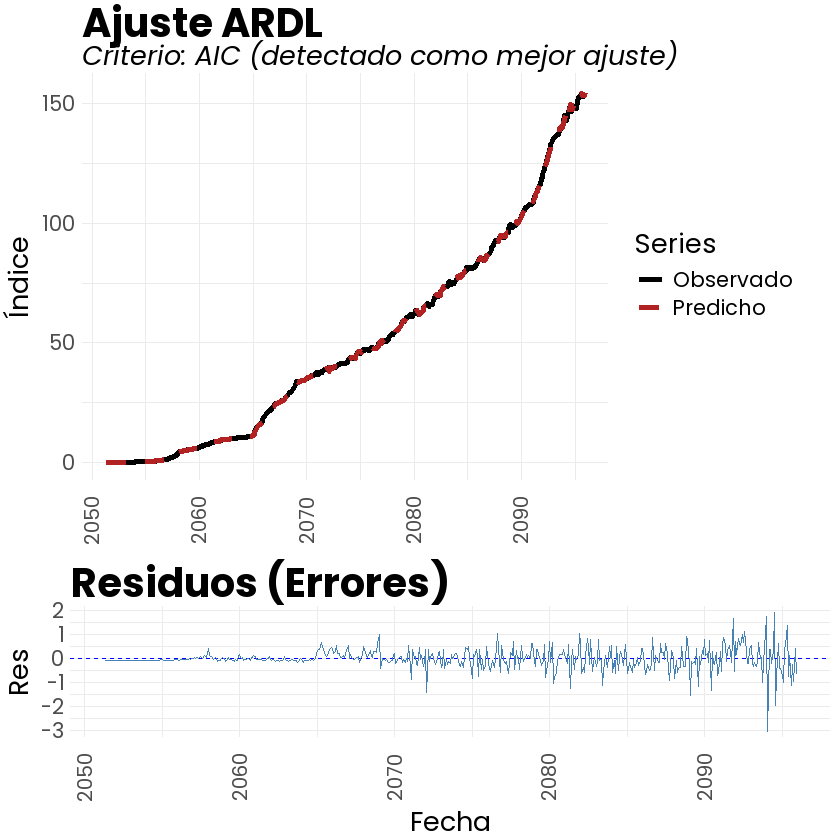

In [176]:
#Ejemplo de implementación
print("Incidencia ferrocarril en alimentos")
alimentos_ferrocarril <- run_ardl_model(
  data =indices,
  date_var = "fecha",
  dep_var = "alimentos_bebidas_tabaco",
  indep_vars = c("ferrocarril"),
  seleccion_modelo = NULL,
  max_order = 4
)


[1] "Incidencia autotransporte de carga en alimentos"

[INFO] Modo automático: Evaluando el modelo más preciso...

   REPORTE FINAL DE MODELO ARDL
Criterio final aplicado: AIC (detectado como mejor ajuste) 
Orden (p, q1, q2...): 3, 3 
Persistencia de la serie: 0 

Time series regression with "ts" data:
Start = 4, End = 540

Call:
dynlm::dynlm(formula = full_formula, data = data, start = start, 
    end = end)

Residuals:
     Min       1Q   Median       3Q      Max 
-3.12642 -0.12799 -0.03494  0.15739  1.86261 

Coefficients:
                               Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     0.06595    0.03440   1.917  0.05573 .  
L(alimentos_bebidas_tabaco, 1)  1.27294    0.04297  29.625  < 2e-16 ***
L(alimentos_bebidas_tabaco, 2) -0.44889    0.06745  -6.655 7.09e-11 ***
L(alimentos_bebidas_tabaco, 3)  0.18191    0.04370   4.163 3.67e-05 ***
autotransporte_carga            0.13759    0.04195   3.280  0.00111 ** 
L(autotransporte_carga, 1)     -0.16

Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.
Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


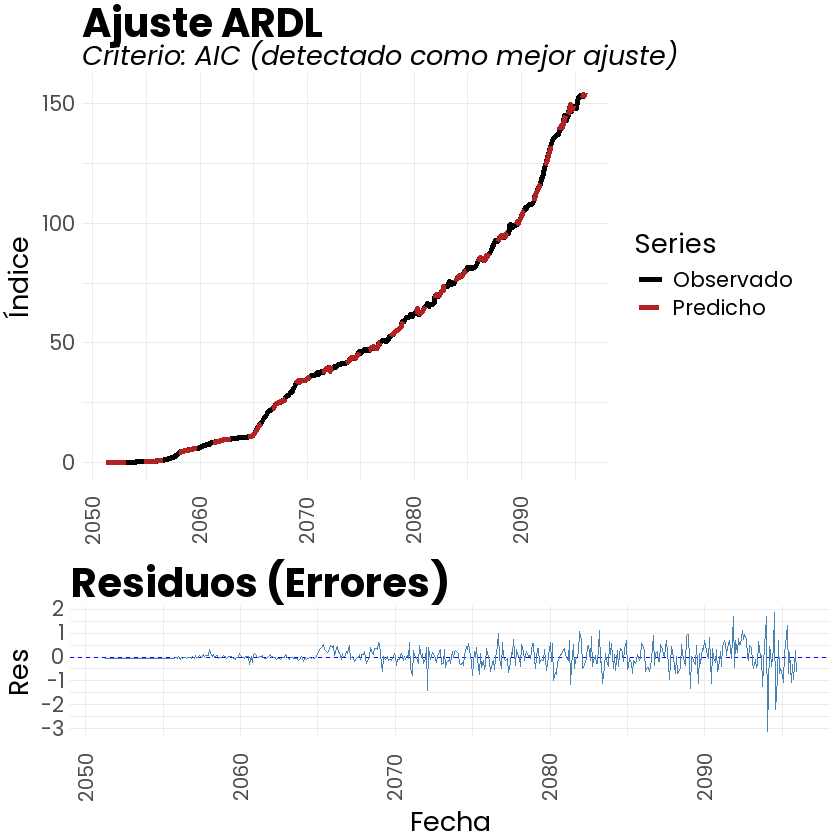

In [177]:
print("Incidencia autotransporte de carga en alimentos")
alimentos_transp_carga <- run_ardl_model(
  data =indices,
  date_var = "fecha",
  dep_var = "alimentos_bebidas_tabaco",
  indep_vars = c("autotransporte_carga"),
  seleccion_modelo = NULL,
  max_order = 4
)